<a href="https://colab.research.google.com/github/harishmuh/Python-for-Data-Science-Analysis/blob/main/Probability_and_central_limit_theorem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Introduction to Statistics II: Probability & Central limit theorem**
___
Previously, we learned that statistics is the study of collecting, analyzing, and interpreting data. Today, humans generate and collect more data than ever before. Every time we send a text message, make an online purchase, or post a photo on social media, we generate new data. As the amount of data increases, so does the need to analyze and interpret it. This is a key reason why statistics and data-driven work are so important. Thus, the field of data analysis is growing almost as rapidly as data itself.

Data professionals use statistics to analyze data in business, medicine, science, engineering, government, and more. Data professionals use the power of statistical methods to identify meaningful patterns and find relationships in data, analyze and quantify uncertainty, generate insights from data, make accurate predictions about the future, and solve complex problems.

Even if we haven't studied statistics, we probably use statistics every day. For example, we start our day by checking the weather online, where we learn that there is a 70 percent chance of rain or a 50 percent chance of snow. Perhaps we visit a sports website to learn about our favorite baseball player's batting average or basketball player's scoring average. In a news app, we might find an election poll that reports a three percent margin of error and notes that an online survey was used to collect the data. Or perhaps we are a parent, and when we take our child for a routine checkup, we learn that their height and weight fall within certain percentiles. When we ask for more information, the doctor shows us the median height and weight for all children the same age. These scenarios involve statistical concepts that we will learn more about.



In [ ]:
# importing libraries

# data manipulation
import numpy as np
import pandas as pd

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# statistics
import statsmodels.api as sm
from scipy import stats

## **1. Probability**

A Data Scientist needs to understand the concept of probability, chance, and probability values. In some statistical tests, decision-making, such as hypothesis testing, is determined by the probability value or P-value.

In statistics, many aspects involve randomness, such as sampling from observations or assigning subjects to treatments, as well as assumptions in hypothesis testing. In each randomization, there is a probability of a particular outcome occurring. The probability of each possibility ranges from 0 to 1.

- Probability is never negative
- A probability of 0 means an event is impossible to occur
- A probability of 1 means an event is certain to occur

To understand probability, let's use the example of a dice roll.

### `Roll a Dice`

When the dice are rolled, the possible outcomes are 1, 2, 3, 4, 5, or 6. However, we don't know exactly which number will appear. The number of times a number, whether 1, 2, 3, 4, 5, or 6, appears in a given number of rolls is an example of probability. The proportion of times a number appears in a given number of rolls of the dice is an example of probability. If the dice are fair, the probability of each number should be 1/3, since there are 6 possible numbers.

We can estimate probability by conducting an experiment. Let's roll the dice 60 times and record the results. If there are 6 numbers, we naturally expect each number to appear 10 times to be fair.

In [ ]:
# Creating functions
def roll_dice(num_rolls):
    np.random.seed(0)
    rolls = [np.random.randint(1,7) for _ in range(num_rolls)]
    return rolls

def plot_results(rolls):
    frequencies = [rolls.count(i) for i in range(1,7)]
    plt.bar(range(1, 7), frequencies, tick_label=[1, 2, 3, 4, 5, 6])
    plt.xlabel('Dice Number')
    plt.ylabel('Frequency')
    plt.title(f'Results of Rolling Dice {len(rolls):,.0f} Times')

But the results of rolling the dice 60 times can be seen in the graph. This is an example of the probability of a given number appearing in several trials.

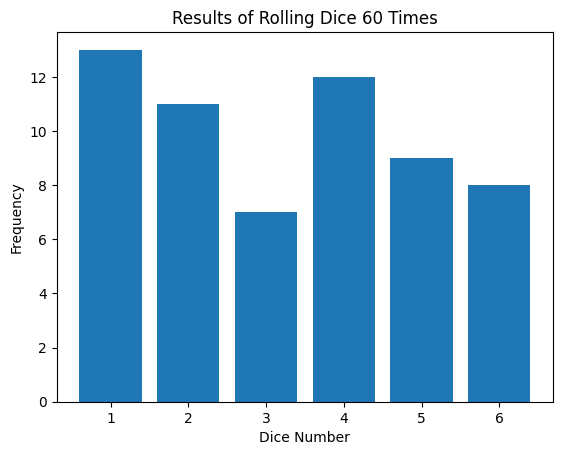

In [ ]:
plot_results(roll_dice(60))

The results of throwing the dice 1,000,000 times can be seen in the following graph, where the more trials there are, the closer the probability is to the theoretical probability.

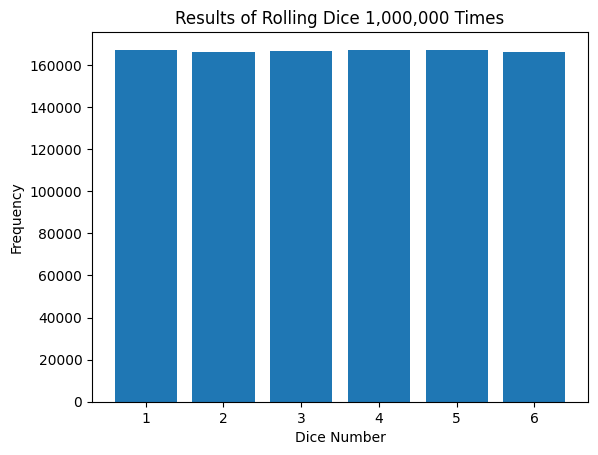

In [ ]:
plot_results(roll_dice(1000000))

### `Terminologies`

There are several terms in probability, including `sample space` and `event`.
- All events that occur are called `sample space` (which can be denoted by $\Omega$).
- Meanwhile, a portion of the sample space, or an individual event that occurs, is called an `event`.

The probability of an event can be calculated using:

$$ P(\text{event}) = \frac{\text{number of outcomes of event}}{\text{number of outcomes in }\Omega} $$

If we only flip a coin once, then there are only two possible outcomes in the sample space $\Omega$: either H or T (using set notation, we can write this as $\Omega$ = {H, T}).

Therefore: $$ P(H) = \frac{1}{2} = 0.5 $$

This is equivalent to: $$ P(T) = \frac{1}{2} = 0.5 $$

As a separate example, consider drawing a card from a standard deck of 52 cards. In this case, the number of possible outcomes in the sample space $\Omega$ is 52.

There is only one ace of spades in a standard deck, so the probability of drawing an ace of spades from the deck is: $$ P(\text{ace of spades}) = \frac{1}{52} \approx 0.019 $$

On the other hand, there are 4 aces, so the probability of drawing an ace from the deck is: $$ P(\text{as}) = \frac{4}{52} \approx 0.077 $$

If we flip a coin twice, the sample space is as follows $\Omega$ = {HH, HT, TH, TT}. So the probability of getting heads in a row is: $$ P(\text{HH}) = \frac{1}{4} = 0.25 $$

### `Basic Operation`

When we roll two dice, the sample space is as follows:

In [ ]:
from itertools import product

first_dice = [1, 2, 3, 4, 5, 6]
second_dice = [1, 2, 3, 4, 5, 6]

list(product(first_dice, second_dice))

[(1, 1),
 (1, 2),
 (1, 3),
 (1, 4),
 (1, 5),
 (1, 6),
 (2, 1),
 (2, 2),
 (2, 3),
 (2, 4),
 (2, 5),
 (2, 6),
 (3, 1),
 (3, 2),
 (3, 3),
 (3, 4),
 (3, 5),
 (3, 6),
 (4, 1),
 (4, 2),
 (4, 3),
 (4, 4),
 (4, 5),
 (4, 6),
 (5, 1),
 (5, 2),
 (5, 3),
 (5, 4),
 (5, 5),
 (5, 6),
 (6, 1),
 (6, 2),
 (6, 3),
 (6, 4),
 (6, 5),
 (6, 6)]

Some possible events or occurrences when rolling two dice are:

| Event | Elementary Outcome | Probability |
| --- | --- | --- |
| The number of seeds is 3 | {(1,2), (2,1)} | $P(A)=\frac{2}{36}$ |
| The number of seeds is 6 | {(1,5), (2,4), (3,3), (4,2), (5,1)} | $P(B)=\frac{5}{36}$ |
| The first die results in a 1 | {(1,1), (1,2), (1,3), (1,4), (1,5), (1,6)} | $P(C)=\frac{6}{36}$ |
| The second die results in a 1 | {(1,1), (2,1), (3,1), (4,1), (5,1), (6,1)} | $P(D)=\frac{6}{36}$ |

We can combine any number of `events` to form another `event` using logical operations. The conjunctions are `and`, `or`, and `not`.

For example, if there are `events` C and D, we can create new `events`:
- C and D: `events` C and D both occur
- C or D: either C or D occurs (or both)
- Not C: `event` C does not occur

Returning to the example of rolling the dice, if C is the event of the first die rolling a 1 and D is the event of the second die rolling a 1, then:

| Event | Elementary Outcome | Probability |
| --- | --- | --- |
| C and D | {(1,1)} | $P\text{(C and D)}=\frac{1}{36}$ |
| C or D | {(1,1), (1,2), (1,3), (1,4), (1,5), (1,6), (2,1), (3,1), (4,1), (5,1), (6,1)} | $P\text{(C or D)}=\frac{11}{36}$ |

This illustration states the addition rule for each event C, D:
$$P\text{(C or D)} = P(C) + P(D) - P\text{(C and D)}$$

For the example above:
$$P\text{(C or D)} = \frac{6}{36} + \frac{6}{36} - \frac{1}{36} = \frac{11}{36}$$

Sometimes the intersection of C and D is empty, and the two events cannot occur together. In this case, we say that C and D are **mutually exclusive**. For mutually exclusive events, we have a special addition rule. If C and D are independent, then:
$$P\text{(C or D)} = P(C) + P(D)$$

Let's say C is a 3-seeded seed or D is a 6-seeded seed, then:
$$P\text{(C or D)} = \frac{2}{36} + \frac{5}{36} = \frac{7}{36}$$

Now, a bit of a **subtraction rule**: for any event C,
$$P(C) = 1 - P\text{(not C)}$$

This is especially useful if $P\text{(not C)}$ is easier to calculate than $P(C)$. Suppose event C, a pair of 1s **does not appear**. Event not C, that is, a pair of 1s appearing, has probability $P\text{(not C)} = \frac{1}{36}$. So:
$$P(C) = 1 - \frac{1}{36} = \frac{35}{36}$$

There's also something called **conditional probability**. Let's say we slightly change our experiment and roll the first die before the second die (not simultaneously). What is the probability that the sum of the numbers on the face is 3 (event A)?

Before the die is rolled, the probability is $P(A) = \frac{2}{36}$.

Now, let's say the first die shows a 1 (event C). What is the probability of A now?

We call this the **conditional probability** that A will occur given that event C has already occurred. We write it as $P(A|C)$, which is the `probability of A, provided that C occurs`.

After event C occurs (the first die shows 1), there is only one outcome, namely (1,2), which totals 3. Therefore, the conditional probability is:
$$P(A|C) = \frac{\text{(1,2)}}{\text{[(1,1), (1,2), (1,3), (1,4), (1,5), (1,6)]}} = \frac{1}{6}$$

Let's translate this formula into a formal formula: the probability of A occurring given C is:
$$P(A|C) = \frac{\text{P(A and C)}}{P(C)}$$

For the dice case, then:
$$P(A|C) = \frac{\text{P(A and C)}}{P(C)} = \frac{\frac{1}{36}}{\frac{1}{6}} = \frac{1}{6}$$

If we rearrange the formula, we get the **multiplication rule**:
$$\text{P(A and C)} = P(A|C)P(C)$$

If A and C are independent, we get the **special multiplication rule**:
$$\text{P(A and C)} = P(A)P(C)$$

### `Probability Distribution`

A probability distribution is a way to summarize each possible outcome and its probability.

There are two types of probability distributions:
- First, the `Probability Mass Distribution` for the probability distribution of discrete data such as the number of dice rolls, the number of students, the population, the number of patients, the number of branch offices, and so on.
- Second, the `Probability Density Distribution` for the probability distribution of continuous data such as the mean value of a sample, salary, inflation, temperature, height, and so on.

There is a terminology called `random variable` that needs to be understood first in probability distributions. A random variable is the numerical outcome of each possible outcome in a random experiment.

For example, if we toss two coins (a random experiment) and record the number of heads: 0, 1, or 2. We can create a table:

| x | 0 | 1 | 2 |
| ---- | --- | --- | --- |
| $P(X=x)$ | $\frac{1}{4}$ | $\frac{2}{4}$ | $\frac{1}{4}$ |

Another example involves rolling two dice. Y represents the sum of the dots on both dice. Since Y is a random variable, it can be anywhere between 2 and 12. The probability distribution would look like this:

| y | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 | 12 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |---|
| $P(Y=y)$ | $\frac{1}{36}$ | $\frac{2}{36}$ | $\frac{3}{36}$ | $\frac{4}{36}$ | $\frac{5}{36}$ | $\frac{6}{36}$ | $\frac{5}{36}$ | $\frac{4}{36}$ | $\frac{3}{36}$ | $\frac{2}{36}$ | $\frac{1}{36}$ |

There are rules to follow.
- First, if all possibilities are added together, the probability value must be one.
- Second, the possibilities must be independent.
- Third, the value of each probability must be between 0 and 1.

The example above is an example of a Probability Mass Distribution.

To make it easier to visualize some types of distributions, here are some examples.

![](https://miro.medium.com/v2/resize:fit:700/0*qxYGR4YXpkVUH88h.png)

Probability distributions are important to understand because they are useful for inferring the most likely event, the probability of an event occurring, and the probability interval between events.

## **2. Sampling Distribution**

A sampling distribution is the probability distribution of a sample statistic. Recall that a probability distribution represents the possible outcomes of a random variable, such as a coin toss or a die roll. Similarly, a sampling distribution represents the possible outcomes of a sample statistic. Sample statistics are based on randomly sampled data, and their outcomes cannot be predicted with certainty. We can use sampling distributions to represent statistics such as the mean, median, standard deviation, range, and others. Typically, data professionals calculate sample statistics such as the mean to estimate the corresponding population parameter.

Suppose we want to estimate the mean of a population, such as the mean height of a group of people, animals, or plants. A good way to understand the concept of a sampling distribution is to imagine that we take repeated samples from the population, each with the same sample size, and calculate the mean for each of these samples. Due to sampling variation, the sample mean will vary from sample to sample in ways that cannot be predicted with certainty. The distribution of all our sample means is essentially a sampling distribution. We can display the distribution of sample means on a histogram. Statisticians call this the sampling distribution of the mean.

### `Simulate random sampling`

In [ ]:
# Loading dataset
url = 'https://raw.githubusercontent.com/harishmuh/Python-for-Data-Science-Analysis/refs/heads/main/datasets/education_districtwise.csv'
education_districtwise = pd.read_csv(url)


In [ ]:
education_districtwise = education_districtwise.dropna() # Dropping missing values
education_districtwise.head()

,DISTNAME,STATNAME,BLOCKS,VILLAGES,CLUSTERS,TOTPOPULAT,OVERALL_LI
0,DISTRICT32,STATE1,13,391,104,875564.0,66.92
1,DISTRICT649,STATE1,18,678,144,1015503.0,66.93
2,DISTRICT229,STATE1,8,94,65,1269751.0,71.21
3,DISTRICT259,STATE1,13,523,104,735753.0,57.98
4,DISTRICT486,STATE1,8,359,64,570060.0,65.00


We will first calculate the mean and standard deviation of the population from the dataset.

In [ ]:
# Mean
population_mean = education_districtwise['OVERALL_LI'].mean()
print('mean of population:', population_mean)

mean of population: 73.39518927444796


In [ ]:
# Standard deviation
population_std = education_districtwise['OVERALL_LI'].std()
print('standard deviation of population:', population_std)

standard deviation of population: 10.098460413782469


We can use Python to simulate random sampling of 50 districts from the dataset. To do this, use pandas.DataFrame.sample(). The following arguments in the sample() function will help us simulate random sampling:

* `n`: Refers to the desired sample size
* `replace`: Indicates whether you are sampling with or without replacement
* `random_state`: Refers to the random number seed

In [ ]:
sampled_data = education_districtwise.sample(n=50, replace=True, random_state=31208)
sampled_data

,DISTNAME,STATNAME,BLOCKS,VILLAGES,CLUSTERS,TOTPOPULAT,OVERALL_LI
661,DISTRICT528,STATE6,9,112,89,1863174.0,92.14
216,DISTRICT291,STATE28,14,1188,165,3273127.0,52.49
367,DISTRICT66,STATE23,12,1169,116,1042304.0,62.14
254,DISTRICT458,STATE3,3,157,19,82839.0,76.33
286,DISTRICT636,STATE35,3,187,44,514683.0,86.70
369,DISTRICT512,STATE23,6,589,30,717169.0,68.35
258,DISTRICT156,STATE3,6,80,9,35289.0,59.94
10,DISTRICT412,STATE1,11,187,95,476820.0,68.69
512,DISTRICT277,STATE9,10,558,179,2298934.0,84.31
144,DISTRICT133,STATE21,14,1672,136,3673849.0,69.61


The output shown shows 50 randomly selected districts from the dataset. Each district has a different literacy rate, but note that row 254 was sampled twice, which is possible because we used sampling with replacement.

Now that you have your random samples, use the mean function to calculate the sample mean. First, name the new variable `estimate1`. Next, use mean() to calculate the `mean` of your sample data.

In [ ]:
estimate1 = sampled_data['OVERALL_LI'].mean()
print(estimate1)

74.22359999999999


The sample mean for the literacy rate is approximately 74.22%. This is a point estimate of the population mean based on a random sample of 50 districts. Remember that the population mean is the literacy rate for all districts. Due to sampling variation, the sample mean is usually not exactly the population mean.

Next, let's see what happens if we calculate the sample mean based on another random sample of 50 districts.

To generate another random sample, name the new variable `estimate2`. Then, set the arguments for the sample function. Again, `n` is 50 and `replace` is "True." This time, choose a different number for our random number seed to generate a different sample: 56,810. Finally, add `mean()` to the end of our code to calculate the sample mean.

In [ ]:
estimate2 = education_districtwise.sample(n=50, replace=True, random_state=56810)['OVERALL_LI'].mean()
print(estimate2)

74.2478


For our second estimate, the sample mean for literacy rates is approximately 74.25%.

Due to sampling variation, this sample mean differs from the sample mean from the previous estimate, which was 74.22%—but the two are very close.

### `Central Limit Theorem`

The Central Limit Theorem states that when the sample size is large enough, the sample mean approaches a normal distribution. And, as we take more observations from the population, the sample mean gets closer to the population mean. The larger our sample size, the more accurate our estimate of the population mean is likely to be.

In this case, the population mean is the overall literacy rate for all districts in the country. Previously, we found that the population mean was 73.39%. Based on the sampling, our first estimate of the sample mean was 74.22%, and the second estimate was 74.24%. Each estimate is quite close to the population mean.

Now, imagine we repeat the study 10,000 times and obtain 10,000 point estimates of the mean. In other words, we take 10,000 random samples from 50 districts and calculate the mean for each sample. According to the Central Limit Theorem, the mean of our sampling distribution will be approximately equal to the population mean.

In [ ]:
estimate_list=[]

for i in range(10000):
    estimate_list.append(education_districtwise['OVERALL_LI'].sample(n=50, replace=True).mean())

estimate_df = pd.DataFrame(data={'estimate': estimate_list})
estimate_df.head()

,estimate
0,76.4294
1,73.8912
2,73.4724
3,71.2806
4,73.3488


In [ ]:
mean_sample_means = estimate_df['estimate'].mean()
print(mean_sample_means)

73.38832864


The mean of the sampling distribution is approximately 73.41%. This mean is quite similar to the population mean of approximately 73.39%.

To visualize the relationship between our estimated 10,000 sample distribution and the normal distribution, we can plot both together.

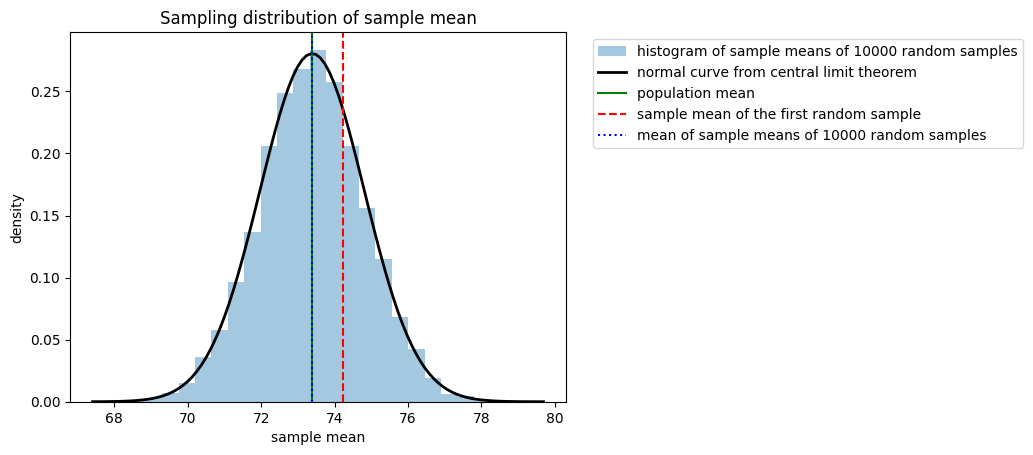

In [ ]:
plt.hist(estimate_df['estimate'], bins=25, density=True, alpha=0.4, label = "histogram of sample means of 10000 random samples")
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100) # generate a grid of 100 values from xmin to xmax.
p = stats.norm.pdf(x, mean_sample_means, stats.tstd(estimate_df['estimate']))
plt.plot(x, p,'k', linewidth=2, label = 'normal curve from central limit theorem')
plt.axvline(x=population_mean, color='g', linestyle = 'solid', label = 'population mean')
plt.axvline(x=estimate1, color='r', linestyle = '--', label = 'sample mean of the first random sample')
plt.axvline(x=mean_sample_means, color='b', linestyle = ':', label = 'mean of sample means of 10000 random samples')
plt.title("Sampling distribution of sample mean")
plt.xlabel('sample mean')
plt.ylabel('density')
plt.legend(bbox_to_anchor=(1.04,1))
plt.show()

Now we will calculate the standard deviation of the sampling distribution.

In [ ]:
std_sample_means = estimate_df['estimate'].std()
print(std_sample_means)

1.422219274886377


The standard deviation of the sampling distribution is 1.4. It should be emphasized that in statistics, the standard deviation of a sampling distribution is known as the **standard error**, which can also be calculated using the formula:
$$SE = \frac{\sigma}{\sqrt{n}}$$

Since we previously calculated the population standard deviation as 10.09, we can calculate the standard error with an n value of 50 as follows:

In [ ]:
standard_error = population_std / np.sqrt(50)
print(standard_error)

1.4281379676258985
